# LLM Augmenté

In [42]:
from langchain_openai import ChatOpenAI

In [43]:
import os

In [44]:
os.environ["OPENAI_API_BASE"] = "http://127.0.0.1:1234/v1"
os.environ["OPENAI_API_KEY"] = "lm_studio"

In [45]:
llm = ChatOpenAI(model="qwen3-1.7b@q6_k")

In [46]:
from pydantic import BaseModel, Field

class SearchQuery(BaseModel):
    search_query: str = Field(None, description="Requete qui optimise la recherche web.")
    justification: str = Field(None, description="Pourquoi cette requete est-elle importante pour la demande de l'utilisateur ?")

structured_llm = llm.with_structured_output(SearchQuery)

output = structured_llm.invoke("Comment le calcium est-il absorbé par le corps humain ?")

print(output.search_query)
print(output.justification)

calcium absorption
the user is asking about how calcium is absorbed by the human body, which is a common question in nutrition and health. The answer should provide an overview of the process, including the role of the digestive system, specific organs involved, and key factors affecting absorption efficiency. It's important to mention both dietary sources and physiological processes that influence calcium uptake.


## Pattern 1: Prompt Chaining

In [47]:
from langgraph.graph import END, START, StateGraph

In [48]:
from typing_extensions import TypedDict, cast

class State(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str

### Noeuds

#### 1. Générer la blague 

In [49]:
def generate_joke(state: State) -> State:
    """Premier appel LLM pour générer une blague à partir du sujet."""
    msg = llm.invoke(f"Ecris une courte blague sur {state['topic']}")
    state['joke'] = f"{msg.content}"
    return state

#### 2. Vérifier s'il y a une punchline

In [50]:
def check_punchline(state: State) -> str:
    """Fonction pour vérifier si la blague a une punchline."""
    # si la blague contient "?" ou "!"
    if "?" in state['joke'] or "!" in state['joke']:
        return "Pass"
    return "Fail"

#### 3. Améliorer la blague

In [51]:
def improve_joke(state: State) -> State:
    """Deuxième appel LLM pour améliorer la blague."""
    msg = llm.invoke(f"Rend la blague plus amusante en ajoutant des jeux de mots : {state['joke']}")
    state['improved_joke'] = f"{msg.content}"
    return state

#### 4. Finalisation de la blague

In [52]:
def polish_joke(state: State) -> State:
    """Troisième appel LLM pour finaliser la blague."""
    msg = llm.invoke(f"Ajoute une surprise à  cette blague : {state['improved_joke']}")
    state['final_joke'] = f"{msg.content}"
    return state

## Construction du Workflow

In [53]:
workflow = StateGraph(State)

#### 1. Ajout  des noeuds

In [54]:
workflow.add_node("generate_joke", generate_joke)
workflow.add_node("improve_joke", improve_joke)
workflow.add_node("polish_joke", polish_joke)

#### 2. Connecter les noeuds

In [55]:
workflow.add_edge(START, "generate_joke")
workflow.add_conditional_edges("generate_joke", check_punchline, {"Fail": "improve_joke", "Pass": END})
workflow.add_edge("improve_joke", "polish_joke")
workflow.add_edge("polish_joke", END)

#### 3. Compiler

In [56]:
chain = workflow.compile()

#### 4. Show workflow

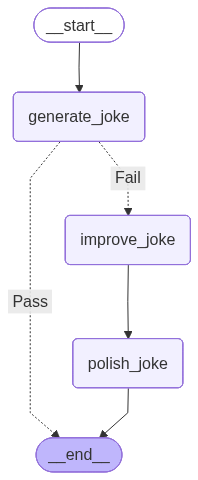

In [57]:
from IPython.display import Image, display
display(Image(chain.get_graph().draw_mermaid_png()))

## Exemple

In [58]:
state = chain.invoke(State({"topic": "les chats", "joke": "", "improved_joke": "", "final_joke": ""}))

print("initial joke: ")
print(state['joke'])
print("\n---------\n")

if state["improved_joke"]:
    print("improved joke: ")
    print(state['improved_joke'])
    print("\n---------\n")

    print("Final joke: ")
    print(state['final_joke'])
else:
    print("Final joke: ")
    print(state['joke'])

initial joke: 


Les chats sont des petits géants dans un monde de miettes ! 🐾

---------

Final joke: 


Les chats sont des petits géants dans un monde de miettes ! 🐾


## Pattern 2: Parallelization

- Example : à partir d'un topic, générer une blague, une blague, une histoire

### Cas d'usage:
- Découper en sous-tâches et les éxecuter en parallèle afin d'améliorer la vitesse
- Exécuter des tâches plusieurs foispour vérifier les différentes sorties

In [59]:
class State(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    combined_output: str

### Noeuds

#### 1. Blague

In [60]:
def call_llm_1(state: State) -> State:
    """1er LLM pour générer la blague."""
    msg = llm.invoke(f"Ecris une blague sur {state['topic']}")
    return {'joke': msg.content}

#### 2. Histoire

In [61]:
def call_llm_2(state: State) -> State:
    """2ème LLM pour générer une histoire."""
    msg = llm.invoke(f"Ecris une histoire sur {state['topic']}")
    return {'story': msg.content}

#### 3. Poème

In [62]:
def call_llm_3(state: State) -> State:
    """3ème LLM pour générer un poème."""
    msg = llm.invoke(f"Ecris un poème sur {state['topic']}")
    return {'poem': msg.content}

#### 4. Aggregateur

In [63]:
def aggregator(state: State) -> State:
    """Combiner les blagues, histoires et poèmes en une sortie."""
    combined = f"Voici une blague, une histoire et un poème sur {state['topic']} :\n\n"
    combined += f"Blague : {state['joke']}\n\n"
    combined += f"Histoire : {state['story']}\n\n"
    combined += f"Poème : {state['poem']}\n\n"
    return {'combined_output': combined}

### Noeuds

In [64]:
from langgraph.graph import END, START, StateGraph

#### 1. Construction des workflows

In [65]:
parallel_builder = StateGraph(State)

#### 2. Ajout des noeuds

In [66]:
parallel_builder.add_node("call_llm_1", call_llm_1)
parallel_builder.add_node("call_llm_2", call_llm_2)
parallel_builder.add_node("call_llm_3", call_llm_3)
parallel_builder.add_node("aggregator", aggregator)

#### 3. Ajout des connexions des noeuds

In [67]:
parallel_builder.add_edge(START, "call_llm_1")
parallel_builder.add_edge(START, "call_llm_2")
parallel_builder.add_edge(START, "call_llm_3")
parallel_builder.add_edge("call_llm_1", "aggregator")
parallel_builder.add_edge("call_llm_2", "aggregator")
parallel_builder.add_edge("call_llm_3", "aggregator")
parallel_builder.add_edge("aggregator", END)

#### 4. Compiler

In [68]:
parallel_workflow = parallel_builder.compile()

#### 5. Afficher le workflow

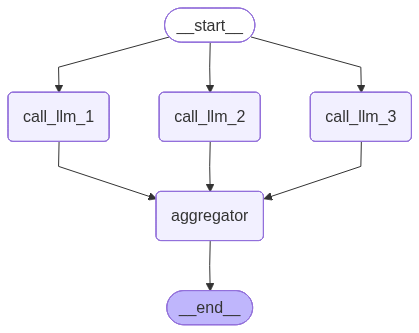

In [69]:
display(Image(parallel_workflow.get_graph().draw_mermaid_png()))

## Exemple

In [70]:
state = parallel_workflow.invoke(State({
    "topic": "Les chiens",
    "joke": "",
    "story": "",
    "poem": "", 
    "combined_output": ""
    }))

print(state['combined_output'])

Voici une blague, une histoire et un poème sur Les chiens :

Blague : 

**"Pourquoi le chien a-t-il des diplômes ? Pour obtenir un meilleur gong ! 😄"**  

*Parfois, les chiens sont aussi intellectuels que les éléphants — mais leur "bac" est toujours en chienne.* 🐶📚

Histoire : 

**Titre : Le Chien qui Faisait la Part du Soleil**  

Dans un petit village perdu à l’ombre des montagnes, où les arbres murmuraient des secrets anciens et les rires des enfants résonnaient comme des notes de musique, vivait un chien nommé Léon. À peine plus grand qu’un chat, il avait des yeux bleus qui reflétait l’éclat du soleil et une queue qui semblait toujours danser avec la lumière. Les habitants le croyaient magique, mais Léon était simplement un chien de rue, né d’une mère riche et d’un père maladroit. Il n’avait pas de maître, ni de propriété, juste une couche de peau et des rêves qui vivaient dans le silence.  

Un jour, un vent froid souffla et emporta Léon avec lui. Le village fut secoué par la tris

# Generator-Elevator

In [71]:
from typing_extensions import Literal, cast

class State(TypedDict):
    topic: str
    joke: str
    feedback: str
    funny_or_not: str

### Structure pour la sortie du LLM

In [72]:
class Feedback(BaseModel):
    grade: Literal["Funny", "Not Funny"] = Field(description="Indique si la blague est drôle ou pas.")
    feedback: str = Field(description="Si la blague n'est pas drôle, donne un feedback sur comment l'améliorer.")

### Augmenter le LLM avec une sortie structurée

In [73]:
evaluator = llm.with_structured_output(Feedback)

### Noeuds

#### 1. Générer la blague

In [74]:
def call_llm_generator(state: State):
    """Appel LLM pour générer une blague à partir du sujet."""
    if state["feedback"]:
        msg = llm.invoke(f"Ecris une blague sur {state['topic']} en tenant compte du feedback suivant : {state['feedback']}")

    else:
        msg = llm.invoke(f"Ecris une blague sur {state['topic']}")
    return {"joke": msg.content}

#### 2. Evaluer la blague

In [75]:
def call_llm_evaluator(state: State):
    """Appel LLM pour évaluer une blague qui a été générée."""
    grade = cast(Feedback, evaluator.invoke(f"Evalue la blague {state['joke']}"))
    print(f"Note: {grade.grade}, Feedback: {grade.feedback}")
    return {"funny_or_not": grade.grade, "feedback": grade.feedback}

#### 3. Edge Conditionnel pour reconduire la blague au generator ou END

In [76]:
def route_joke(state: State):
    """Renvoyer ou terminer suivant le feedback de l'evaluator."""
    if state['funny_or_not'] == "funny":
        return "Accepted"
    elif state["funny_or_not"] == "not_funny":
        return "Rejected + Feedback"

### Construction du workflow

In [77]:
optimizer_builder = StateGraph(State)

### Ajout des noeuds au workflow

In [78]:
optimizer_builder.add_node("call_llm_generator", call_llm_generator)
optimizer_builder.add_node("call_llm_evaluator", call_llm_evaluator)

### Ajout des edges (liens des noeuds)

In [79]:
optimizer_builder.add_edge(START, "call_llm_generator")
optimizer_builder.add_edge("call_llm_generator", "call_llm_evaluator")
optimizer_builder.add_conditional_edges(
    "call_llm_evaluator",
    route_joke,
    {
        "Accepted": END,
        "Rejected + Feedback": "call_llm_generator",
    }
)

### Compiler le workflow

In [80]:
optimizer_workflow = optimizer_builder.compile()

### Afficher le workflow

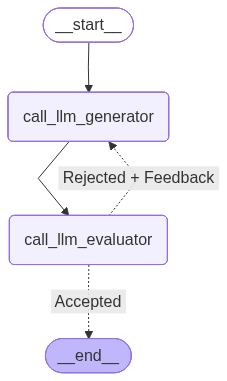

In [81]:
display(Image(optimizer_workflow.get_graph().draw_mermaid_png()))

### Générer la blague

In [82]:
state = optimizer_workflow.invoke(
    State({"topic": "les chats", "joke": "", "feedback": ""})
)
print(state["joke"])

Note: Not Funny, Feedback: Ces mots sont trop classiques et ne montrent pas d'humour ou de surprise. Le message est trop simple et ne fait pas vraiment une blague.


KeyError: None

## Agents

In [83]:
from langchain.tools import tool

### Tools

In [84]:
@tool
def multiply(a: int, b: int) -> int:
    """Multiplie a et b
    args:
        a: first int
        b: second int
   """
    return a * b

@tool
def add(a: int, b: int) -> int:
    """Additionne a et b
    args:
        a: first int
        b: second int
   """
    return a + b

@tool

def divide(a: int, b: int) -> int:
    """Divise a par b
    args:
        a: first int
        b: second int
   """
    if b == 0:
        return "Error: Division by zero"
    return a / b

### Augmenter le LLM avec les tools

In [85]:
tools = [add, multiply, divide]
tools_by_name = {tool.name: tool for tool in tools}
llm_with_tools = llm.bind_tools(tools)

### Appel LLM

In [86]:
from langgraph.graph import MessagesState
from langchain.messages import SystemMessage, HumanMessage, ToolMessage

In [87]:
def llm_call(state: MessagesState):
    """LLM decide entre appeler un outil ou non"""

    return {
        "messages": [
            llm_with_tools.invoke(
                [
                    SystemMessage(
                        content="Tu es un assistant qui peut faire des calculs mathématiques qui réalise des calculs arithmétiques sur les données à l'entrée."
                    )
                ] + state["messages"]
            )
        ]
    }

### Edge conditionnel pour décider si le LLM continue le tool call ou renvoie le résultat

In [88]:
def should_continue(state: MessagesState)-> Literal["tool_node", END]:
    """Decide si on continue la boucle d'appel des tools ou non."""
    messages = state["messages"]
    last_message = messages[-1]

    # Si le LLM fait un appel de tools, réaliser l'action
    if last_message.tool_calls:
        return "tool_node"
    
    # Sinon on stock et on returne à l'utilisateur
    return END

### Workflow

In [89]:
from langgraph.prebuilt import ToolNode

#### 1. Build workflow

In [90]:
agent_builder = StateGraph(MessagesState)

#### 2. Ajouter les noeuds

In [91]:
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", ToolNode(tools))

#### 3. Connexion des noeuds

In [92]:
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    ["tool_node", END]
)
agent_builder.add_edge("tool_node", "llm_call")

#### 4. Compiler

In [93]:
agent = agent_builder.compile()

#### 5. Afficher le workflow de l'agent

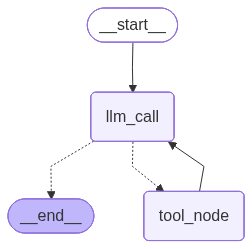

In [94]:
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

### Invoke

In [95]:
messages = [HumanMessage(content="additionne 3 et 4")]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

additionne 3 et 4
================================== Ai Message ==================================
Tool Calls:
  add (674928742)
 Call ID: 674928742
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================



La somme de 3 et 4 est égale à $3 + 4 = 7$. 

Réponse finale : $\boxed{7}$


## MCP

In [96]:
import asyncio
from langchain_mcp_adapters.client import MultiServerMCPClient
from langchain.agents import create_agent

In [ ]:
async def main():
    client = MultiServerMCPClient(
        {
            "Test MCP": {
                "Transport": "stdio", # fichier local
                "command": "uv",
                "args": [
                    "run",
                    "--with",
                    "fastmcp",
                    "fastmcp",
                    "run",
                    "C:\\Users\\ODC\\Desktop\\Didier\\agent-llm\\test_mcp.py"
                ]
            }
        }
    )

    tools = await client.get_tools()
    print(tools)
    llm_with_tools = llm.bind_tools(tools)
    def llm_call(state: MessagesState):
        """LLM decide entre appeler un outil ou non"""

        return {
            "messages": [
                llm_with_tools.invoke(
                    [
                        SystemMessage(
                            content="Tu es un agent qui peut appeler des outils pour résoudre des problèmes."
                        )
                    ] + state["messages"]
                )
            ]
        }
    
    def tool_node(state: dict):
        """Appelle l'outil choisi par le LLM"""
        tool_calls = state["messages"][-1].tool_calls
        results = []
        for tool_call in tool_calls:
            tool_name = tool_call["name"]
            observation = tool.invoke(tool_call["args"])
            results.append(
                ToolMessage(content=observation, tool_call_id=tool_call["id"])
            )
        return {"messages": results}
    
    def should_continue(state: dict):
        """Decide si on continue la boucle d'appel des tools ou non."""
        messages = state["messages"]
        last_message = messages[-1]

        # Si le LLM fait un appel de tools, réaliser l'action
        if last_message.tool_calls:
            return "Action"
        
        # Sinon on stock et on returne à l'utilisateur
        return END
    
    # Créer le graphe d'exécution de l'agent
    agent_builder = StateGraph(MessagesState)
    agent_builder.add_node("llm", llm_call)
    agent_builder.add_node("Action", tool_node)
    agent_builder

if __name__ == "__main__":
    asyncio.run(main())